# Hybrid SARIMA-NNAR Model - Time Series Analysis (Series 1)

## Objective

This notebook develops a hybrid forecasting model for the time series of Grip cases for individuals aged 15 years and older in Barcelona City, using weekly data for the period 2012–2024.

The starting point is the final SARIMA model selected in the previous notebook, which captures the linear and seasonal structure of the series. Then, a neural network autoregressive model (NNAR) is incorporated to model possible nonlinear patterns remaining in the SARIMA residuals. The final hybrid forecast is obtained by combining the SARIMA forecast with the residual forecast provided by the NNAR model. In particular, the neural network uses as inputs the most recent residual lags and one seasonal lag at 52 weeks, which is consistent with the annual seasonality of the weekly series.

## Methodology

The procedure followed in this notebook is the following:

1. Load the final SARIMA model selected in the previous notebook and fit it on the training period
2. Extract the SARIMA residuals from the training set
3. Perform an exploratory analysis of the residuals in order to assess whether they still contain structure that may justify a nonlinear model
4. Construct a supervised learning matrix from the SARIMA residuals, using short-term lags and one seasonal lag
5. Split the residual series into a training and validation segment, preserving the temporal order
6. Perform a small grid search over the number of short lags and hidden units
7. Select the best configuration according to the validation error
8. Refit the selected neural network on the full residual training set
9. Generate recursive forecasts of the residual component and combine them additively with the SARIMA forecasts

Thus, the final hybrid forecast is obtained as the sum of:
- the SARIMA forecast, which captures the linear and seasonal component
- the seasonal NNAR forecast on the residuals, which aims to capture any remaining nonlinear structure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import acf
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_HYBRID = "#C2185B" 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

In [2]:
df_serie = df[
    (df["diagnostic"] == "Grip") &
    (df["nom_regio"] == "Barcelona Ciutat") &
    (df["edat_bin"] == "15+")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

In [3]:
serie_1 = serie.copy()

train = serie_1[serie_1.index < "2020-01-01"]
test  = serie_1[serie_1.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


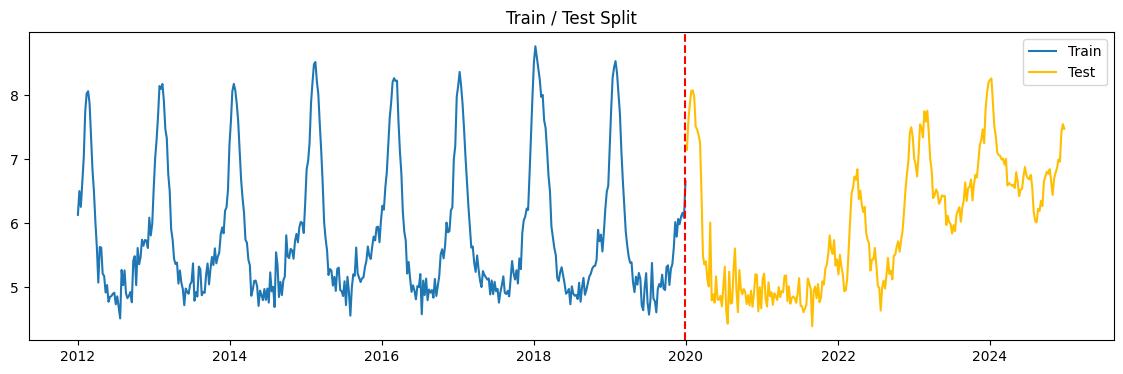

In [4]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print(train_log.index.min(), train_log.index.max())
print(test_log.index.min(), test_log.index.max())

plt.figure(figsize=(14,4))

plt.plot(train_log, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test_log, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train_log.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Train / Test Split")
plt.show()

In [5]:
model = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)

## Residual extraction and exploratory analysis

In this section, the residuals of the fitted SARIMA model are extracted from the training set. These residuals represent the part of the series that remains unexplained after modelling its main linear and seasonal behaviour.

Once the residuals are extracted, an exploratory analysis is carried out. First, their main descriptive statistics are computed. Then, the residuals are plotted over time in order to inspect their general behaviour. Their distribution is examined through a QQ-plot, while a scatter plot is also included to visualise their dispersion and detect possible unusual observations

Their dependence structure is analysed through the autocorrelation function (ACF). In addition, the autocorrelation of squared residuals is studied to detect possible variance effects or remaining nonlinear patterns. Finally, formal statistical tests are included: the Ljung–Box test is used to assess remaining autocorrelation, the ARCH test is used to detect conditional heteroscedasticity.

The purpose of this step is to evaluate whether the residuals behave approximately as white noise or whether they still contain structure that may justify the use of an NNAR model.

Burn-in used: 107
Residual mean: 0.001068173749429341
Residual std: 0.2559004776798135
Relative mean (|mean| / std): 0.004174176457637785


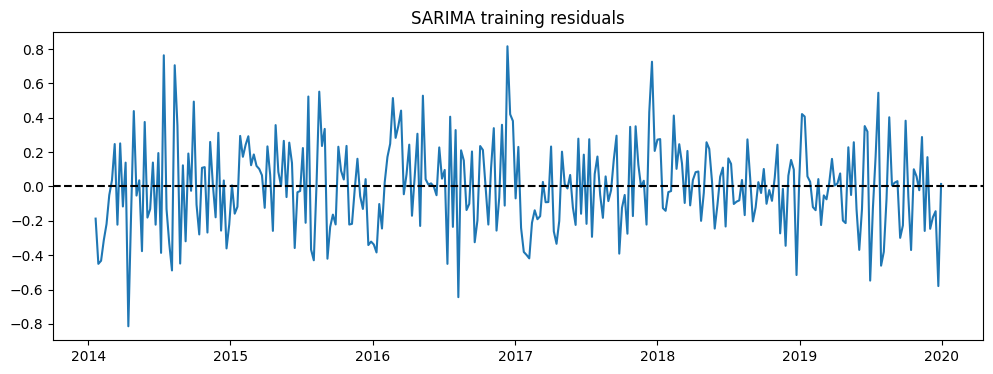

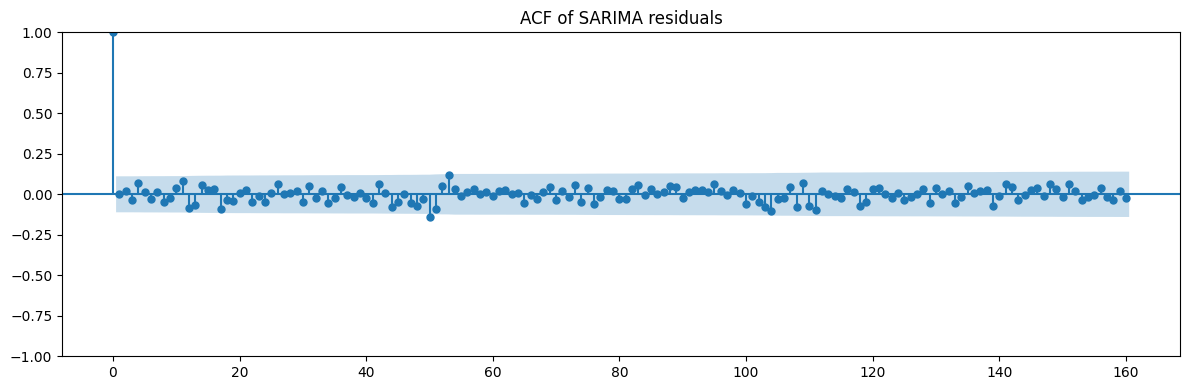


Ljung-Box test:
      lb_stat  lb_pvalue
10   3.938588   0.950075
20  15.360695   0.755410
30  19.630341   0.925812

Ljung-Box on seasonal lags test:
       lb_stat  lb_pvalue
52   43.391575   0.796566
104  78.295061   0.971775


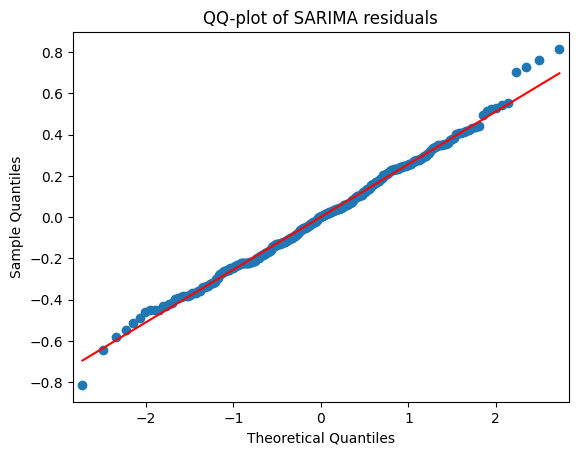

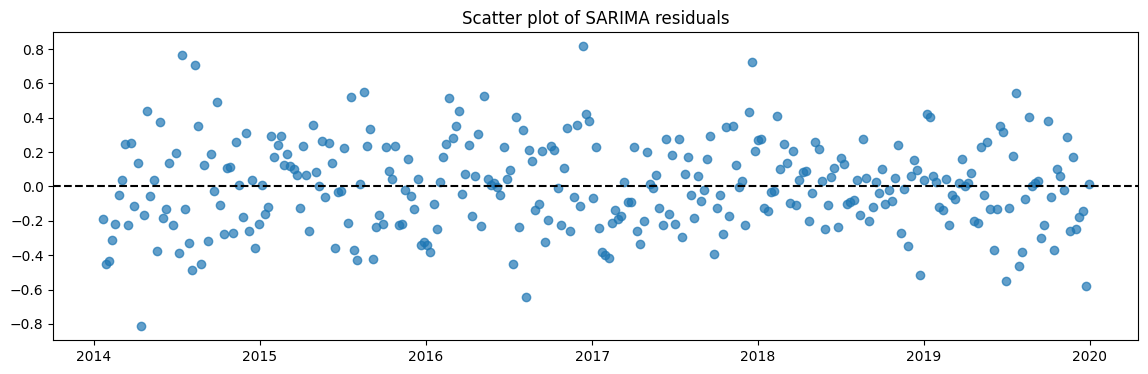

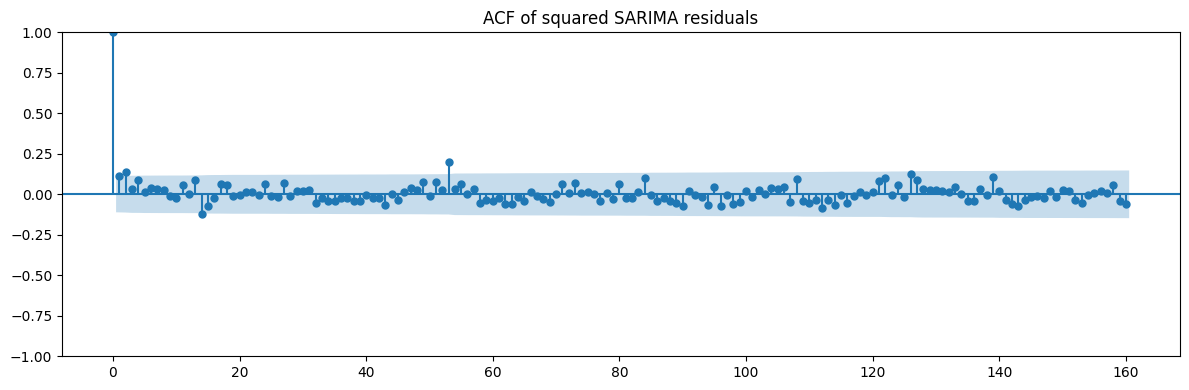


ARCH test p-value: 0.3518247350284322


In [6]:
residuals= result.resid.dropna()
burn = max(result.loglikelihood_burn, result.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residuals_train = residuals.iloc[burn:].copy()

print("Residual mean:", residuals_train.mean())
print("Residual std:", residuals_train.std())
print("Relative mean (|mean| / std):", abs(residuals_train.mean()) / residuals_train.std())

#Residual Time plot
plt.figure(figsize=(12, 4))
plt.plot(residuals_train)
plt.axhline(0, color="black", linestyle="--")
plt.title("SARIMA training residuals")
plt.show()

#ACF of residuals
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residuals_train, lags=160, ax=ax)

ax.set_title("ACF of SARIMA residuals")
plt.tight_layout()
plt.show()

#Ljung-Box test
ljung_box = acorr_ljungbox(residuals_train, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box test:")
print(ljung_box)

#Ljung-Box of seasonal lags
ljung_box_seasonal = acorr_ljungbox(residuals_train,lags=[52, 104],return_df=True)

print("\nLjung-Box on seasonal lags test:")
print(ljung_box_seasonal)

#QQ-plot
sm.qqplot(residuals_train, line="s")
plt.title("QQ-plot of SARIMA residuals")
plt.show()

#Scatter plot
plt.figure(figsize=(14, 4))
plt.scatter(residuals_train.index, residuals_train, alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.title("Scatter plot of SARIMA residuals")
plt.show()

#ACF of squared residuals
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residuals_train**2, lags=160, ax=ax)

ax.set_title("ACF of squared SARIMA residuals")
plt.tight_layout()
plt.show()

#ARCH test
arch_test = het_arch(residuals_train, nlags=10)
print("\nARCH test p-value:", arch_test[1])


## Residual exploratory results

The residual diagnostics indicate that the fitted SARIMA model removes a large part of the linear dependence of the series. In particular, the Ljung–Box and ARCH test results do not show strong evidence of remaining autocorrelation or conditional heteroscedasticity. However, the graphical analysis still allows us to explore whether some mild nonlinear or local patterns may remain in the residual series.

For this reason, an NNAR model is considered as a possible complementary component. The aim is to evaluate whether modeling the residuals can provide a small forecasting improvement over the SARIMA model alone.

## Construction of the supervised residual matrix

To fit the neural network, the SARIMA residual series is transformed into a supervised learning problem.

For each observation, the predictors are:
- the previous p residual values, which represent short-term dependence
- one seasonal lag at 52 weeks, which represents annual seasonal dependence

The target variable is the current residual value. After shifting the series to create these predictors, the initial observations with missing lag values are removed.

This transformation allows the residual time series to be treated as a regression problem, while still preserving its temporal structure.

In [7]:
SEASONAL_LAG = 52

ROLLING_START_FRAC = 0.7
ROLLING_HORIZON = 26
ROLLING_STEP = 26

p_list = [2, 3, 4, 5, 6, 8, 12]
hidden_list = [2, 3, 4, 6, 8]

def create_nnar_matrix(series, p=2, seasonal_lag=52):
    df = pd.DataFrame({"y": series})

    for i in range(1, p + 1):
        df[f"lag_{i}"] = series.shift(i)

    df[f"lag_seasonal_{seasonal_lag}"] = series.shift(seasonal_lag)

    df = df.dropna()

    X = df.drop(columns="y")
    y = df["y"]

    return X, y

## Grid search for the seasonal NNAR hyperparameters

A small grid search is performed to determine the most suitable seasonal NNAR specification for the residual series.

Two hyperparameters are explored:

- p: number of short residual lags used as inputs
- h: number of neurons in the hidden layer

The seasonal component is fixed at one lag of 52 weeks, so the model can be interpreted as a simple seasonal NNAR (p, P, h, m) structure with:

- P = 1
- m = 52

The candidate models are evaluated using a rolling validation scheme, which is more appropriate for time series than a single fixed split. In each fold, the model is trained on the initial part of the residual series and then used to recursively predict the following validation block. The training window is then expanded and the process is repeated over several folds.

The models are compared using rolling MAE and rolling RMSE. In this notebook, greater importance is given to rolling RMSE, since it penalizes larger forecast errors more strongly.

In [8]:
results_grid = []

n_total = len(residuals_train)
min_start = SEASONAL_LAG + max(p_list) + 10
start = max(int(np.floor(ROLLING_START_FRAC * n_total)), min_start)

for p in p_list:
    for hidden in hidden_list:
        fold_mae_list = []
        fold_rmse_list = []
        n_folds = 0

        end_train = start

        while end_train + ROLLING_HORIZON <= n_total:
            train_cv = residuals_train.iloc[:end_train].copy()
            val_cv = residuals_train.iloc[end_train:end_train + ROLLING_HORIZON].copy()

            X_train_nn, y_train_nn = create_nnar_matrix(
                train_cv,
                p=p,
                seasonal_lag=SEASONAL_LAG
            )

            if len(X_train_nn) == 0:
                end_train += ROLLING_STEP
                continue

            scaler_X = StandardScaler()
            scaler_y = StandardScaler()

            X_train_scaled = scaler_X.fit_transform(X_train_nn)
            y_train_scaled = scaler_y.fit_transform(y_train_nn.to_frame()).ravel()

            nnar_model = MLPRegressor(
                hidden_layer_sizes=(hidden,),
                activation="relu",
                solver="lbfgs",
                alpha=1e-4,
                max_iter=5000,
                random_state=42
            )

            nnar_model.fit(X_train_scaled, y_train_scaled)

            history = list(train_cv.values)
            pred_cv = []

            for _ in range(len(val_cv)):
                row_next = {}

                for i in range(1, p + 1):
                    row_next[f"lag_{i}"] = history[-i]

                row_next[f"lag_seasonal_{SEASONAL_LAG}"] = history[-SEASONAL_LAG]

                X_next = pd.DataFrame([row_next], columns=X_train_nn.columns)
                X_next_scaled = scaler_X.transform(X_next)

                pred_next_scaled = nnar_model.predict(X_next_scaled)
                pred_next = scaler_y.inverse_transform(
                    pred_next_scaled.reshape(-1, 1)
                ).ravel()[0]

                pred_cv.append(pred_next)
                history.append(pred_next)

            pred_cv = pd.Series(pred_cv, index=val_cv.index)

            mae_cv = mean_absolute_error(val_cv, pred_cv)
            rmse_cv = root_mean_squared_error(val_cv, pred_cv)

            fold_mae_list.append(mae_cv)
            fold_rmse_list.append(rmse_cv)
            n_folds += 1

            end_train += ROLLING_STEP

        if n_folds > 0:
            results_grid.append({
                "p": p,
                "P": 1,
                "m": SEASONAL_LAG,
                "hidden_units": hidden,
                "rolling_MAE": np.mean(fold_mae_list),
                "rolling_RMSE": np.mean(fold_rmse_list),
                "n_folds": n_folds
            })

results_grid = (
    pd.DataFrame(results_grid)
    .sort_values(["rolling_RMSE", "rolling_MAE"])
    .reset_index(drop=True)
)

print("\nTop 5 configurations by rolling MAE")
display(
    results_grid
    .sort_values(["rolling_MAE", "rolling_RMSE"])
    .head(5)
    .reset_index(drop=True)
)

print("\nTop 5 configurations by rolling RMSE")
display(
    results_grid
    .sort_values(["rolling_RMSE", "rolling_MAE"])
    .head(5)
    .reset_index(drop=True)
)


Top 5 configurations by rolling MAE


,p,P,m,hidden_units,rolling_MAE,rolling_RMSE,n_folds
0,3,1,52,4,0.156648,0.204141,3
1,2,1,52,3,0.157785,0.202944,3
2,2,1,52,2,0.158562,0.205856,3
3,4,1,52,2,0.160160,0.204953,3
4,3,1,52,2,0.160309,0.205273,3



Top 5 configurations by rolling RMSE


,p,P,m,hidden_units,rolling_MAE,rolling_RMSE,n_folds
0,2,1,52,3,0.157785,0.202944,3
1,3,1,52,4,0.156648,0.204141,3
2,4,1,52,2,0.160160,0.204953,3
3,3,1,52,2,0.160309,0.205273,3
4,2,1,52,8,0.162718,0.205377,3


In [9]:
best_config = results_grid[
    (results_grid["p"] == 2) &
    (results_grid["hidden_units"] == 3)
].iloc[0]

best_p = int(best_config["p"])
best_hidden = int(best_config["hidden_units"])

print("Selected seasonal NNAR configuration")
print(f"p = {best_p}")
print("P = 1")
print(f"m = {SEASONAL_LAG}")
print(f"hidden_units = {best_hidden}")
print(f"Rolling MAE = {best_config['rolling_MAE']:.6f}")
print(f"Rolling RMSE = {best_config['rolling_RMSE']:.6f}")
print(f"Number of folds = {best_config['n_folds']}")

Selected seasonal NNAR configuration
p = 2
P = 1
m = 52
hidden_units = 3
Rolling MAE = 0.157785
Rolling RMSE = 0.202944
Number of folds = 3.0


## Final seasonal NNAR fit on the full residual training set

For this series, the chosen seasonal NNAR model is NNAR(p=2, P=1, h=3, m=52).

Once the best hyperparameters have been selected, the seasonal NNAR model is fitted again using the full residual training set. This final fit uses all available residual information from the training period, so that the neural network can be used to generate recursive forecasts for the test horizon.

In [10]:
X_full_nn, y_full_nn = create_nnar_matrix(residuals_train, p=best_p, seasonal_lag=SEASONAL_LAG)

scaler_X_final = StandardScaler()
scaler_y_final = StandardScaler()

X_full_scaled = scaler_X_final.fit_transform(X_full_nn)
y_full_scaled = scaler_y_final.fit_transform(y_full_nn.to_frame()).ravel()

nnar_final = MLPRegressor(
    hidden_layer_sizes=(best_hidden,),
    activation="relu",
    solver="lbfgs",
    alpha=1e-4,
    max_iter=5000,
    random_state=42
)

nnar_final.fit(X_full_scaled, y_full_scaled);

## Recursive residual forecasting and hybrid prediction

The residual forecasts are generated recursively. This means that the neural network predicts the next residual value using the most recent available lags and the seasonal lag. Then, each predicted residual is incorporated into the history and used to predict the following one. This recursive strategy is necessary because, in the forecasting horizon, the future residuals are unknown and must therefore be generated step by step.

Finally, the residual forecasts obtained from the seasonal NNAR model are added to the SARIMA forecasts in the log-transformed scale. The resulting hybrid forecasts are then transformed back to the original scale for interpretation and comparison with the observed series.

In this way, the hybrid model combines:
- the linear and seasonal structure captured by SARIMA
- the possible nonlinear residual structure captured by the seasonal NNAR model

In [11]:
def recursive_nnar_forecast(model, history, horizon, p, seasonal_lag, scaler_X, scaler_y, forecast_index):
    preds = []
    history = list(history)

    for _ in range(horizon):
        row = {}

        for i in range(1, p + 1):
            row[f"lag_{i}"] = history[-i]

        row[f"lag_seasonal_{seasonal_lag}"] = history[-seasonal_lag]

        X_next = pd.DataFrame([row])
        X_next_scaled = scaler_X.transform(X_next)

        pred_scaled = model.predict(X_next_scaled)
        pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()[0]

        preds.append(pred)
        history.append(pred)

    return pd.Series(preds, index=forecast_index)

## Prediction intervals for the hybrid model

For the SARIMA model, prediction intervals are directly obtained from the fitted model.  
For the hybrid SARIMA + NNAR approach, this is not as straightforward, since the neural network component does not provide exact analytical prediction intervals.

To address this, the hybrid intervals are constructed through simulation. First, future paths are simulated for the SARIMA component. Then, future residual paths are recursively generated for the NNAR component, adding resampled past errors (bootstrap) to reflect uncertainty. Finally, both parts are combined and the 2.5% and 97.5% quantiles of the simulated paths are taken as the lower and upper bounds of the 95% prediction interval.

Therefore, these intervals should be interpreted as empirical / approximate prediction intervals, not exact analytical ones.

In [12]:
def hybrid_pi_short(
    sarima_result,
    nnar_model,
    scaler_X,
    scaler_y,
    residuals_train,
    X_train_nnar,
    y_train_nnar,
    p,
    seasonal_lag,
    forecast_index,
    n_sims=300,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)
    h = len(forecast_index)

    X_scaled = scaler_X.transform(X_train_nnar)
    yhat_scaled = nnar_model.predict(X_scaled)
    yhat = scaler_y.inverse_transform(yhat_scaled.reshape(-1, 1)).ravel()

    nnar_errors = np.asarray(y_train_nnar) - yhat
    nnar_errors = nnar_errors - nnar_errors.mean()

    err_low, err_high = np.quantile(nnar_errors, [0.01, 0.99])
    nnar_errors = np.clip(nnar_errors, err_low, err_high)

    sarima_sim = np.asarray(
        sarima_result.simulate(
            nsimulations=h,
            repetitions=n_sims,
            anchor="end",
            random_state=seed
        )
    )

    if sarima_sim.ndim == 1:
        sarima_sim = sarima_sim.reshape(h, 1)
    elif sarima_sim.shape == (n_sims, h):
        sarima_sim = sarima_sim.T

    hybrid_sim = np.zeros((h, n_sims))
    base_history = list(np.asarray(residuals_train, dtype=float))

    resid_low, resid_high = np.quantile(base_history, [0.01, 0.99])

    for b in range(n_sims):
        history = base_history.copy()

        for t in range(h):
            row = {f"lag_{i}": history[-i] for i in range(1, p + 1)}
            row[f"lag_seasonal_{seasonal_lag}"] = history[-seasonal_lag]

            X_next = pd.DataFrame([row])
            X_next_scaled = scaler_X.transform(X_next)

            pred_scaled = nnar_model.predict(X_next_scaled)
            pred_resid = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()[0]

            next_resid = pred_resid + rng.choice(nnar_errors)
            next_resid = np.clip(next_resid, resid_low, resid_high)
            history.append(next_resid)

            total_log = sarima_sim[t, b] + next_resid
            total_log = np.clip(total_log, -20, 20)
            hybrid_sim[t, b] = np.expm1(total_log)

    lower = pd.Series(np.quantile(hybrid_sim, alpha / 2, axis=1), index=forecast_index)
    upper = pd.Series(np.quantile(hybrid_sim, 1 - alpha / 2, axis=1), index=forecast_index)
    median = pd.Series(np.quantile(hybrid_sim, 0.5, axis=1), index=forecast_index)

    return lower, upper, median

In [13]:
#SARIMA forecast
pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

#NNAR residual forecast
nnar_resid_forecast = recursive_nnar_forecast(
    model=nnar_final,
    history=residuals_train.values,
    horizon=len(test_log),
    p=best_p,
    seasonal_lag=SEASONAL_LAG,
    scaler_X=scaler_X_final,
    scaler_y=scaler_y_final,
    forecast_index=test_log.index
)

hybrid_pred_mean_log = pred_mean_log + nnar_resid_forecast

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log)
hybrid_pred_mean = np.expm1(hybrid_pred_mean_log)

hybrid_ci_lower, hybrid_ci_upper, hybrid_ci_median = hybrid_pi_short(
    sarima_result=result,
    nnar_model=nnar_final,
    scaler_X=scaler_X_final,
    scaler_y=scaler_y_final,
    residuals_train=residuals_train,
    X_train_nnar=X_full_nn,     
    y_train_nnar=y_full_nn,     
    p=best_p,
    seasonal_lag=SEASONAL_LAG,
    forecast_index=test.index,
    n_sims=300,
    alpha=0.05,
    seed=42
)

## SARIMA vs hybrid model

The final step is to compare the predictive performance of the SARIMA model and the hybrid SARIMA + seasonal NNAR model on the test period. The comparison is based on MAE, RMSE and MAPE, together with the percentage improvement of the hybrid model relative to the SARIMA benchmark.

To obtain a more detailed assessment, the comparison is carried out over the full test period and separately for the COVID (2020–2021) and post-COVID (2022–2024) subperiods. Prediction intervals are also considered: SARIMA intervals are obtained directly from the fitted model, while hybrid intervals are approximated through simulation. Their empirical coverage is then evaluated, and the numerical results are complemented with a visual inspection of the forecasts against the observed series.

In [14]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

hybrid_covid = hybrid_pred_mean["2020":"2021"]
hybrid_post = hybrid_pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

hybrid_ci_covid_lower = hybrid_ci_lower["2020":"2021"]
hybrid_ci_covid_upper = hybrid_ci_upper["2020":"2021"]

hybrid_ci_post_lower = hybrid_ci_lower["2022":"2024"]
hybrid_ci_post_upper = hybrid_ci_upper["2022":"2024"]

mae_sarima_total = mean_absolute_error(test, pred_mean)
rmse_sarima_total = root_mean_squared_error(test, pred_mean)
mape_sarima_total = mean_absolute_percentage_error(test, pred_mean) * 100
cov_sarima_total = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

mae_hybrid_total = mean_absolute_error(test, hybrid_pred_mean)
rmse_hybrid_total = root_mean_squared_error(test, hybrid_pred_mean)
mape_hybrid_total = mean_absolute_percentage_error(test, hybrid_pred_mean) * 100
cov_hybrid_total = ((test >= hybrid_ci_lower) & (test <= hybrid_ci_upper)).mean()

mae_sarima_covid = mean_absolute_error(test_covid, pred_covid)
rmse_sarima_covid = root_mean_squared_error(test_covid, pred_covid)
mape_sarima_covid = mean_absolute_percentage_error(test_covid, pred_covid) * 100
cov_sarima_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

mae_hybrid_covid = mean_absolute_error(test_covid, hybrid_covid)
rmse_hybrid_covid = root_mean_squared_error(test_covid, hybrid_covid)
mape_hybrid_covid = mean_absolute_percentage_error(test_covid, hybrid_covid) * 100
cov_hybrid_covid = ((test_covid >= hybrid_ci_covid_lower) & (test_covid <= hybrid_ci_covid_upper)).mean()

mae_sarima_post = mean_absolute_error(test_post, pred_post)
rmse_sarima_post = root_mean_squared_error(test_post, pred_post)
mape_sarima_post = mean_absolute_percentage_error(test_post, pred_post) * 100
cov_sarima_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

mae_hybrid_post = mean_absolute_error(test_post, hybrid_post)
rmse_hybrid_post = root_mean_squared_error(test_post, hybrid_post)
mape_hybrid_post = mean_absolute_percentage_error(test_post, hybrid_post) * 100
cov_hybrid_post = ((test_post >= hybrid_ci_post_lower) & (test_post <= hybrid_ci_post_upper)).mean()

table_total = pd.DataFrame({
    "Model": ["SARIMA", "Hybrid"],
    "MAE": [mae_sarima_total, mae_hybrid_total],
    "RMSE": [rmse_sarima_total, rmse_hybrid_total],
    "MAPE": [mape_sarima_total, mape_hybrid_total],
    "Coverage": [cov_sarima_total, cov_hybrid_total]
}).round({"MAE": 3, "RMSE": 3, "MAPE": 3, "Coverage": 3 })

table_covid = pd.DataFrame({
    "Model": ["SARIMA", "Hybrid"],
    "MAE": [mae_sarima_covid, mae_hybrid_covid],
    "RMSE": [rmse_sarima_covid, rmse_hybrid_covid],
    "MAPE": [mape_sarima_covid, mape_hybrid_covid],
    "Coverage": [cov_sarima_covid, cov_hybrid_covid]
}).round({"MAE": 3, "RMSE": 3, "MAPE": 3, "Coverage": 3})

table_post = pd.DataFrame({
    "Model": ["SARIMA", "Hybrid"],
    "MAE": [mae_sarima_post, mae_hybrid_post],
    "RMSE": [rmse_sarima_post, rmse_hybrid_post],
    "MAPE": [mape_sarima_post, mape_hybrid_post],
    "Coverage": [cov_sarima_post, cov_hybrid_post]
}).round({"MAE": 3, "RMSE": 3, "MAPE": 3, "Coverage": 3})

print("\nTOTAL:")
display(table_total)

print("\nCOVID (2020–2021):")
display(table_covid)

print("\nPOST-COVID (2022–2024):")
display(table_post)



TOTAL:


,Model,MAE,RMSE,MAPE,Coverage
0,SARIMA,503.553,780.289,152.896,0.585
1,Hybrid,500.924,773.328,150.710,0.642



COVID (2020–2021):


,Model,MAE,RMSE,MAPE,Coverage
0,SARIMA,337.325,691.959,206.337,0.808
1,Hybrid,331.800,681.376,202.183,0.827



POST-COVID (2022–2024):


,Model,MAE,RMSE,MAPE,Coverage
0,SARIMA,614.371,833.995,117.269,0.436
1,Hybrid,613.674,828.982,116.395,0.519


In [15]:
improvement_table = pd.DataFrame({
    "Period": ["Total", "COVID (2020–2021)", "Post-COVID (2022–2024)"],
    "MAE improvement (%)": [
        100 * (mae_sarima_total - mae_hybrid_total) / mae_sarima_total,
        100 * (mae_sarima_covid - mae_hybrid_covid) / mae_sarima_covid,
        100 * (mae_sarima_post - mae_hybrid_post) / mae_sarima_post
    ],
    "RMSE improvement (%)": [
        100 * (rmse_sarima_total - rmse_hybrid_total) / rmse_sarima_total,
        100 * (rmse_sarima_covid - rmse_hybrid_covid) / rmse_sarima_covid,
        100 * (rmse_sarima_post - rmse_hybrid_post) / rmse_sarima_post
    ],
    "MAPE improvement (%)": [
        100 * (mape_sarima_total - mape_hybrid_total) / mape_sarima_total,
        100 * (mape_sarima_covid - mape_hybrid_covid) / mape_sarima_covid,
        100 * (mape_sarima_post - mape_hybrid_post) / mape_sarima_post
    ]
})

improvement_table = improvement_table.round(3)
display(improvement_table)

,Period,MAE improvement (%),RMSE improvement (%),MAPE improvement (%)
0,Total,0.522,0.892,1.430
1,COVID (2020–2021),1.638,1.529,2.013
2,Post-COVID (2022–2024),0.114,0.601,0.745


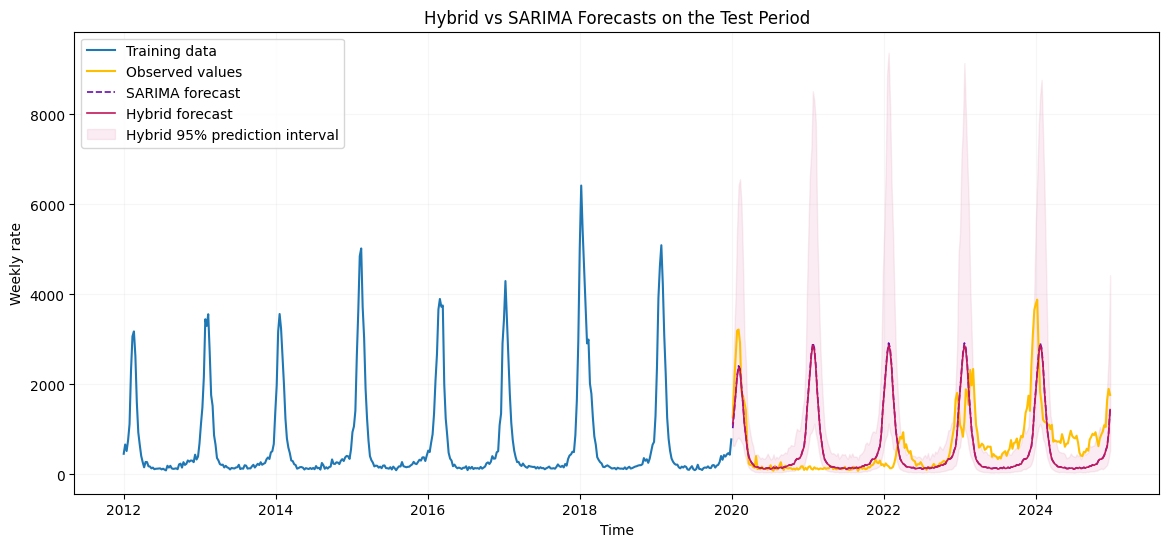

In [16]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Training data', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Observed values', color=COLOR_OBS, linewidth=1.5)

plt.plot(pred_mean, label='SARIMA forecast', color=COLOR_FORECAST, linewidth=1.2, linestyle='--')
plt.plot(hybrid_pred_mean, label='Hybrid forecast', color=COLOR_HYBRID, linewidth=1.2)

plt.fill_between(
    hybrid_ci_lower.index,
    hybrid_ci_lower.values,
    hybrid_ci_upper.values,
    color=COLOR_HYBRID,
    alpha=0.08,
    label='Hybrid 95% prediction interval'
)

plt.legend()
plt.title("Hybrid vs SARIMA Forecasts on the Test Period")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.grid(alpha=0.1)
plt.show()

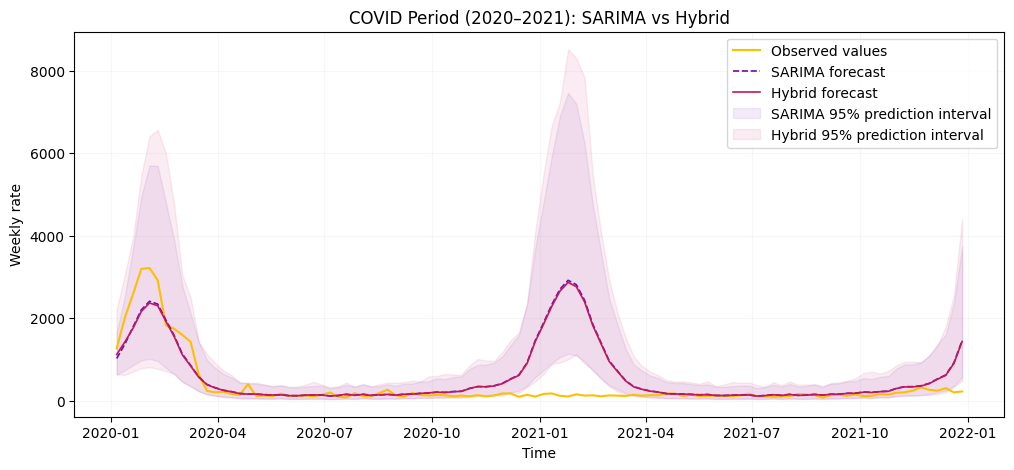

In [17]:
hybrid_covid = hybrid_pred_mean["2020":"2021"]

plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='SARIMA forecast', color=COLOR_FORECAST, linewidth=1.2, linestyle='--')
plt.plot(hybrid_covid, label='Hybrid forecast', color=COLOR_HYBRID, linewidth=1.2)

plt.fill_between(
    ci_covid.index,
    ci_covid.iloc[:, 0],
    ci_covid.iloc[:, 1],
    color=COLOR_FORECAST,
    alpha=0.08,
    label='SARIMA 95% prediction interval'
)

plt.fill_between(
    hybrid_ci_covid_lower.index,
    hybrid_ci_covid_lower.values,
    hybrid_ci_covid_upper.values,
    color=COLOR_HYBRID,
    alpha=0.08,
    label='Hybrid 95% prediction interval'
)

plt.title("COVID Period (2020–2021): SARIMA vs Hybrid")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

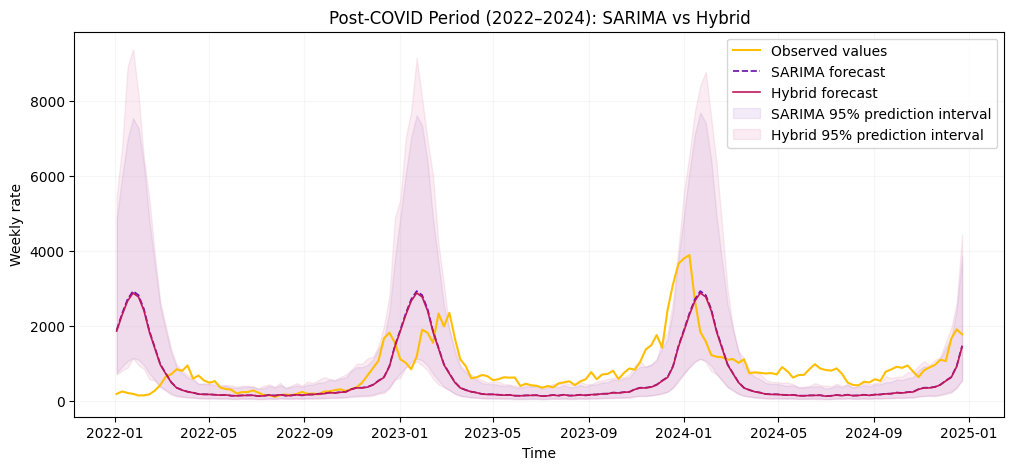

In [18]:
hybrid_post = hybrid_pred_mean["2022":"2024"]

plt.figure(figsize=(12,5))

plt.plot(test_post, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='SARIMA forecast', color=COLOR_FORECAST, linewidth=1.2, linestyle='--')
plt.plot(hybrid_post, label='Hybrid forecast', color=COLOR_HYBRID, linewidth=1.2)

plt.fill_between(
    ci_post.index,
    ci_post.iloc[:, 0],
    ci_post.iloc[:, 1],
    color=COLOR_FORECAST,
    alpha=0.08,
    label='SARIMA 95% prediction interval'
)

plt.fill_between(
    hybrid_ci_post_lower.index,
    hybrid_ci_post_lower.values,
    hybrid_ci_post_upper.values,
    color=COLOR_HYBRID,
    alpha=0.08,
    label='Hybrid 95% prediction interval'
)

plt.title("Post-COVID Period (2022–2024): SARIMA vs Hybrid")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

## Final interpretation of the results

The hybrid SARIMA + seasonal NNAR model provides a modest but consistent improvement over SARIMA alone. Over the full test period, the hybrid reduces point forecast errors by 0.52% in MAE, 0.89% in RMSE, and 1.43% in MAPE, showing that the NNAR component adds a small but useful nonlinear correction.

The improvement is more noticeable during the COVID period (2020–2021), with gains of 1.64% in MAE, 1.53% in RMSE, and 2.01% in MAPE. In the post-COVID period (2022–2024), the gains remain positive but smaller: 0.11% in MAE, 0.60% in RMSE, and 0.74% in MAPE.

The hybrid model also shows higher empirical coverage than SARIMA in all periods, suggesting that its prediction bands capture the observed values slightly better. However, these hybrid intervals are simulation-based approximations, so they should be interpreted only as an exploratory measure of uncertainty rather than as exact analytical confidence intervals.

Overall, the forecast plots support this interpretation: the hybrid forecast remains close to the SARIMA forecast, but its small nonlinear adjustments are enough to produce slightly better accuracy and somewhat better empirical coverage. Therefore, in this series, the hybrid model is a useful complement to SARIMA, although the overall improvement remains moderate.